# NLP Task 4: Topic Modeling (LDA / NMF / LSI)
## 1. Data Loading & Exploration

Dataset: sklearn `fetch_20newsgroups` — ~18,000 newsgroup documents across 20 categories

In [3]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
# Visualization
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [6]:
# 20 newsgroups
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({'text': newsgroups.data, 'target': newsgroups.target})
df['category'] = df['target'].apply(lambda x: newsgroups.target_names[x])

print(f'Dataset shape: {df.shape}')
print(f'Number of categories: {df["category"].nunique()}')
print()
df.head()

Dataset shape: (18846, 3)
Number of categories: 20



,text,target,category
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


In [7]:
print('Category distribution:')
print(df['category'].value_counts().head(15))
print()
df['text_len'] = df['text'].astype(str).apply(len)
print('Text length stats:')
print(df['text_len'].describe())

Category distribution:
category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
sci.med                     990
rec.autos                   990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
Name: count, dtype: int64

Text length stats:
count     18846.000000
mean       1169.667516
std        3858.748875
min           0.000000
25%         234.000000
50%         489.000000
75%         979.000000
max      158791.000000
Name: text_len, dtype: float64


## 2. Preprocessing

Steps:
1. Convert to lowercase
2. Remove punctuation and numbers
3. Remove English stop words (built into sklearn)
4. Filter short words (len <= 2)

In [8]:
# English stop words from sklearn (built-in)
# We'll use the stop_words parameter in the vectorizers directly.
# Here we define a simple preprocessing function for raw text cleaning.

def preprocess_text(text):
    """Preprocess text: lowercase -> remove punctuation/numbers -> remove short words"""
    if not isinstance(text, str):
        return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers, keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. Filter short words
    tokens = [t for t in text.split() if len(t) > 2]
    return ' '.join(tokens)

print('Preprocessing function ready')

Preprocessing function ready


In [9]:
# Apply preprocessing to all texts
print('Preprocessing...')
df['clean_text'] = df['text'].apply(preprocess_text)

# Remove empty texts
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Done. Documents remaining: {len(df)}')
print()
print('Example:')
print('Original (first 200 chars):', str(df['text'].iloc[0])[:200])
print()
print('Cleaned  (first 200 chars):', df['clean_text'].iloc[0][:200])

Preprocessing...
Done. Documents remaining: 18307

Example:
Original (first 200 chars): 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However,

Cleaned  (first 200 chars): sure some bashers pens fans are pretty confused about the lack any kind posts about the recent pens massacre the devils actually bit puzzled too and bit relieved however going put end non pittsburgher


## 3. Vectorization

- **LDA** uses `CountVectorizer` (word frequency matrix)
- **NMF / LSI** use `TfidfVectorizer`

Parameters:
- `stop_words='english'`: built-in English stop words
- `min_df=5`: word must appear in at least 5 documents
- `max_df=0.7`: ignore words appearing in >70% of documents
- `ngram_range=(1,1)`: unigrams only (bigrams add noise in topic modeling)
- `max_features=10000`: cap vocabulary size

In [10]:
# Vectorization parameters
VEC_PARAMS = {
    'stop_words': 'english',
    'min_df': 5,
    'max_df': 0.7,
    'ngram_range': (1, 1),
    'max_features': 10000,
}

# LDA uses CountVectorizer (word frequency)
count_vec = CountVectorizer(**VEC_PARAMS)
dtm_count = count_vec.fit_transform(df['clean_text'])
print(f'CountVectorizer matrix: {dtm_count.shape}')

# NMF / LSI use TfidfVectorizer
tfidf_vec = TfidfVectorizer(**VEC_PARAMS)
dtm_tfidf = tfidf_vec.fit_transform(df['clean_text'])
print(f'TfidfVectorizer matrix: {dtm_tfidf.shape}')

CountVectorizer matrix: (18307, 10000)
TfidfVectorizer matrix: (18307, 10000)


## 4 、 5. Train Models + Select Optimal k

For k=2..25, train three models and compute:
- **Coherence (c_v)**: using gensim CoherenceModel
- **Perplexity**: LDA only (sklearn built-in)

Select k_opt: maximum coherence or minimum perplexity

In [12]:
# Prepare gensim format for coherence calculation
texts_for_coherence = [text.split() for text in df['clean_text']]
dictionary = Dictionary(texts_for_coherence)

def get_top_words(model, feature_names, n_top=10):
    """Extract top n words for each topic"""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

def calc_coherence(topics, texts, dictionary):
    """Calculate c_v coherence"""
    cm = CoherenceModel(topics=topics, texts=texts,
                        dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

In [13]:
# Train all three models for k=2..25
K_RANGE = range(2, 26)

lda_coherences = []
lda_perplexities = []
nmf_coherences = []
lsi_coherences = []

lda_models = {}
nmf_models = {}
lsi_models = {}

count_feature_names = count_vec.get_feature_names_out()
tfidf_feature_names = tfidf_vec.get_feature_names_out()

print('Training models (k=2..25)...')
for k in K_RANGE:
    print(f'  k={k}...', end=' ')

    # LDA (learning_method='online' for speed on large datasets)
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        max_iter=15, learning_method='online'
    )
    lda.fit(dtm_count)
    lda_topics = get_top_words(lda, count_feature_names)
    lda_coherences.append(calc_coherence(lda_topics, texts_for_coherence, dictionary))
    lda_perplexities.append(lda.perplexity(dtm_count))
    lda_models[k] = lda

    # NMF
    nmf = NMF(n_components=k, random_state=42, max_iter=150)
    nmf.fit(dtm_tfidf)
    nmf_topics = get_top_words(nmf, tfidf_feature_names)
    nmf_coherences.append(calc_coherence(nmf_topics, texts_for_coherence, dictionary))
    nmf_models[k] = nmf

    # LSI (TruncatedSVD — already fast)
    lsi = TruncatedSVD(n_components=k, random_state=42)
    lsi.fit(dtm_tfidf)
    lsi_topics = get_top_words(lsi, tfidf_feature_names)
    lsi_coherences.append(calc_coherence(lsi_topics, texts_for_coherence, dictionary))
    lsi_models[k] = lsi

    print('done')

print('\nTraining complete!')

Training models (k=2..25)...
  k=2... done
  k=3... done
  k=4... done
  k=5... done
  k=6... done
  k=7... done
  k=8... done
  k=9... done
  k=10... done
  k=11... done
  k=12... done
  k=13... done
  k=14... done
  k=15... done
  k=16... done
  k=17... done
  k=18... done
  k=19... done
  k=20... done
  k=21... done
  k=22... done
  k=23... done
  k=24... done
  k=25... done

Training complete!


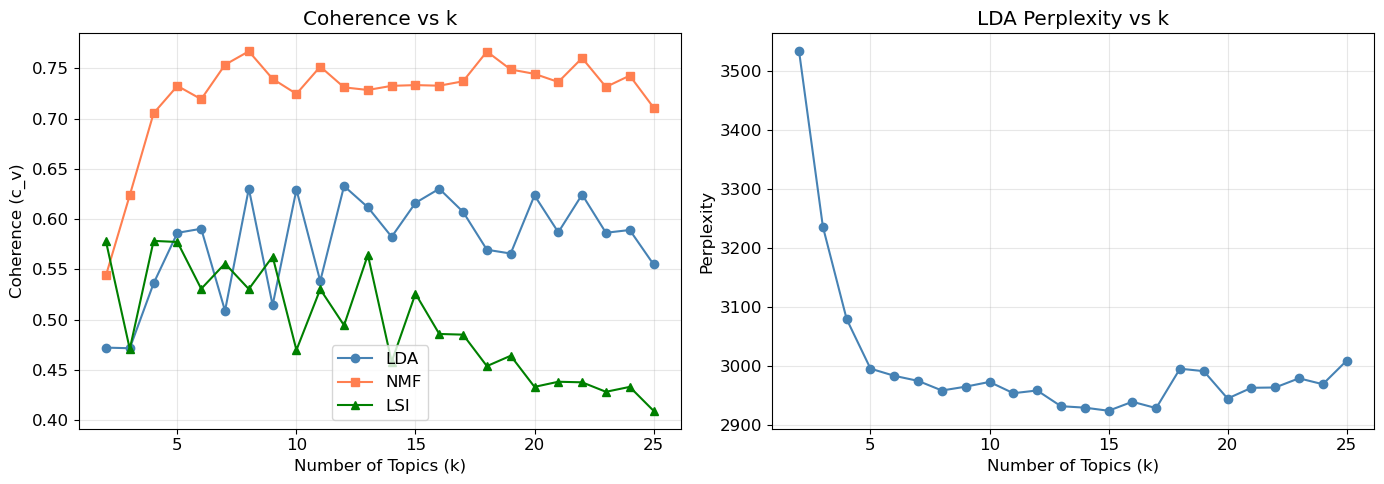

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(K_RANGE), lda_coherences, 'o-', label='LDA', color='steelblue')
ax.plot(list(K_RANGE), nmf_coherences, 's-', label='NMF', color='coral')
ax.plot(list(K_RANGE), lsi_coherences, '^-', label='LSI', color='green')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Coherence (c_v)')
ax.set_title('Coherence vs k')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(list(K_RANGE), lda_perplexities, 'o-', color='steelblue')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Perplexity')
ax.set_title('LDA Perplexity vs k')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Find optimal k
k_list = list(K_RANGE)
k_opt_lda = k_list[np.argmax(lda_coherences)]
k_opt_nmf = k_list[np.argmax(nmf_coherences)]
k_opt_lsi = k_list[np.argmax(lsi_coherences)]

print('Optimal k (by max coherence):')
print(f'  LDA: k={k_opt_lda}, coherence={max(lda_coherences):.4f}')
print(f'  NMF: k={k_opt_nmf}, coherence={max(nmf_coherences):.4f}')
print(f'  LSI: k={k_opt_lsi}, coherence={max(lsi_coherences):.4f}')
print()

k_opt_lda_perp = k_list[np.argmin(lda_perplexities)]
print(f'LDA optimal k (by min perplexity): k={k_opt_lda_perp}, perplexity={min(lda_perplexities):.2f}')

Optimal k (by max coherence):
  LDA: k=12, coherence=0.6329
  NMF: k=8, coherence=0.7669
  LSI: k=4, coherence=0.5784

LDA optimal k (by min perplexity): k=15, perplexity=2923.93


## 6. Model Comparison

Using each model's optimal k, display Top 10 words for 5 topics

In [16]:
def display_topics(model, feature_names, n_top=10, n_topics=5):
    """Show top n_topics topics, each with top n_top words"""
    for idx in range(min(n_topics, len(model.components_))):
        top_indices = model.components_[idx].argsort()[:-n_top - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f'  Topic {idx}: {" | ".join(top_words)}')

print(f'=== LDA (k={k_opt_lda}) ===')
display_topics(lda_models[k_opt_lda], count_feature_names)
print()

print(f'=== NMF (k={k_opt_nmf}) ===')
display_topics(nmf_models[k_opt_nmf], tfidf_feature_names)
print()

print(f'=== LSI (k={k_opt_lsi}) ===')
display_topics(lsi_models[k_opt_lsi], tfidf_feature_names)

=== LDA (k=12) ===
  Topic 0: file | windows | use | dos | program | image | using | files | window | problem
  Topic 1: space | government | president | use | new | public | center | technology | national | research
  Topic 2: car | light | earth | power | cars | high | parts | engine | problem | speed
  Topic 3: max | game | team | games | year | play | season | hockey | players | league
  Topic 4: edu | com | mail | ftp | list | available | send | pub | email | internet

=== NMF (k=8) ===
  Topic 0: people | don | just | think | like | right | know | time | good | did
  Topic 1: thanks | know | does | mail | advance | info | email | looking | information | address
  Topic 2: god | jesus | bible | christ | believe | christian | faith | christians | sin | church
  Topic 3: drive | scsi | card | disk | hard | ide | drives | controller | bus | mac
  Topic 4: game | games | team | year | hockey | baseball | season | players | play | espn

=== LSI (k=4) ===
  Topic 0: don | know | like | 

In [17]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['LDA', 'NMF', 'LSI'],
    'Optimal k': [k_opt_lda, k_opt_nmf, k_opt_lsi],
    'Coherence (c_v)': [
        max(lda_coherences),
        max(nmf_coherences),
        max(lsi_coherences)
    ]
})
print('Model comparison:')
print(comparison.to_string(index=False))

best_model_name = comparison.loc[comparison['Coherence (c_v)'].idxmax(), 'Model']
best_k = int(comparison.loc[comparison['Coherence (c_v)'].idxmax(), 'Optimal k'])
print(f'\nBest model: {best_model_name} (k={best_k}, highest coherence)')

Model comparison:
Model  Optimal k  Coherence (c_v)
  LDA         12         0.632901
  NMF          8         0.766904
  LSI          4         0.578381

Best model: NMF (k=8, highest coherence)


## 7. Demo Function

Input: text string  
Output: list of k (topic, weight/probability) pairs + top words per topic

In [18]:
def predict_topics(text, model, vectorizer, feature_names,
                   n_top_words=10, preprocess=True):
    """
    Input a text string, return topic distribution and keywords per topic.

    Args:
        text: input text
        model: trained topic model (LDA/NMF/LSI)
        vectorizer: corresponding vectorizer
        feature_names: feature name list
        n_top_words: number of keywords per topic
        preprocess: whether to preprocess input text

    Returns:
        List of (topic_id, weight, top_words)
    """
    if preprocess:
        text = preprocess_text(text)

    # Vectorize
    dtm = vectorizer.transform([text])

    # Get topic distribution
    topic_dist = model.transform(dtm)[0]

    # Sort by weight descending
    sorted_indices = np.argsort(topic_dist)[::-1]

    results = []
    for idx in sorted_indices:
        top_word_indices = model.components_[idx].argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        results.append((f'Topic {idx}', topic_dist[idx], top_words))

    return results


def display_prediction(text, model, vectorizer, feature_names, n_top=10):
    """Display topic prediction for a single text"""
    results = predict_topics(text, model, vectorizer, feature_names, n_top)
    print(f'Input: {text[:100]}...')
    print('-' * 60)
    for topic_name, weight, words in results:
        if weight > 0.01:  # Only show topics with weight > 1%
            print(f'  {topic_name} (weight={weight:.4f}): {" | ".join(words)}')
    print()

print('Demo functions ready')

Demo functions ready


In [19]:
# 5 new texts for demonstration (not from training set)
test_texts = [
    "The president held a meeting with government officials on economic policy and trade agreements.",
    "The national football team won their qualifying match 3-1 with an outstanding performance.",
    "Scientists discovered a new species of deep-sea fish near hydrothermal vents in the Pacific Ocean.",
    "Stock markets rallied today as the Federal Reserve announced a cut in interest rates.",
    "The new space telescope captured stunning images of distant galaxies billions of light years away.",
]

# Select best model for prediction
if best_model_name == 'LDA':
    best_model = lda_models[best_k]
    best_vec = count_vec
    best_features = count_feature_names
elif best_model_name == 'NMF':
    best_model = nmf_models[best_k]
    best_vec = tfidf_vec
    best_features = tfidf_feature_names
else:
    best_model = lsi_models[best_k]
    best_vec = tfidf_vec
    best_features = tfidf_feature_names

print(f'Using best model: {best_model_name} (k={best_k})')
print('=' * 60)

for i, text in enumerate(test_texts, 1):
    print(f'\n[Example {i}]')
    display_prediction(text, best_model, best_vec, best_features)

Using best model: NMF (k=8)

[Example 1]
Input: The president held a meeting with government officials on economic policy and trade agreements....
------------------------------------------------------------
  Topic 6 (weight=0.0218): key | chip | clipper | encryption | keys | government | use | escrow | phone | algorithm


[Example 2]
Input: The national football team won their qualifying match 3-1 with an outstanding performance....
------------------------------------------------------------
  Topic 4 (weight=0.0490): game | games | team | year | hockey | baseball | season | players | play | espn


[Example 3]
Input: Scientists discovered a new species of deep-sea fish near hydrothermal vents in the Pacific Ocean....
------------------------------------------------------------


[Example 4]
Input: Stock markets rallied today as the Federal Reserve announced a cut in interest rates....
------------------------------------------------------------


[Example 5]
Input: The new space tel

In [20]:
# Compare all three models on the same text
print('Three-model comparison on one text:')
print('=' * 60)
sample_text = test_texts[0]
print(f'Text: {sample_text[:100]}...\n')

for name, model, vec, feats, k in [
    ('LDA', lda_models[k_opt_lda], count_vec, count_feature_names, k_opt_lda),
    ('NMF', nmf_models[k_opt_nmf], tfidf_vec, tfidf_feature_names, k_opt_nmf),
    ('LSI', lsi_models[k_opt_lsi], tfidf_vec, tfidf_feature_names, k_opt_lsi),
]:
    print(f'--- {name} (k={k}) ---')
    results = predict_topics(sample_text, model, vec, feats)
    for topic_name, weight, words in results:
        if weight > 0.01:
            print(f'  {topic_name} (w={weight:.4f}): {" | ".join(words)}')
    print()

Three-model comparison on one text:
Text: The president held a meeting with government officials on economic policy and trade agreements....

--- LDA (k=12) ---
  Topic 1 (w=0.7161): space | government | president | use | new | public | center | technology | national | research
  Topic 11 (w=0.2006): people | armenian | government | israel | jews | armenians | war | said | state | turkish

--- NMF (k=8) ---
  Topic 6 (w=0.0218): key | chip | clipper | encryption | keys | government | use | escrow | phone | algorithm

--- LSI (k=4) ---
  Topic 0 (w=0.0358): don | know | like | just | people | think | does | use | good | time

